In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Zentrale Einstellungen, damit die Abstände und Farben der vier Abbildungen konsistent bleiben.
BENCHMARK_FILES = {
    "auto-pyTorch": {
        300: "benchm_autopytorch_excw-10_traintime-300.json",
        600: "benchm_autopytorch_excw-10_traintime-600.json",
    },
    "auto-sklearn": {
        300: "benchm_autosklearn_excw-10_traintime-300.json",
        600: "benchm_autosklearn_excw-10_traintime-600.json",
    },
    "AutoGluon": {
        300: "benchm_autogluon_excw-10_traintime-300.json",
        600: "benchm_autogluon_excw-10_traintime-600.json",
    },
}

frameworks = ["auto-pyTorch", "auto-sklearn", "AutoGluon"]
time_limits = [300, 600]


def load_benchmarks(files):
    """Lädt die Benchmark-Ergebnisse einmal und hält die Daten zentral verfügbar."""
    benchmarks = {}

    for framework in frameworks:
        benchmarks[framework] = {}
        for limit in time_limits:
            with open(files[framework][limit], "r") as f:
                benchmarks[framework][limit] = json.load(f)

    return benchmarks


benchmarks = load_benchmarks(BENCHMARK_FILES)


## Hilfsfunktionen

Die folgenden Funktionen übernehmen nur wiederkehrende Schritte. Die eigentliche Auswertung und Darstellung bleibt in den jeweiligen Abschnitten sichtbar.

In [ ]:
def find_result(results, task, task_type=None):
    for result in results:
        if result.get("task") == task and (task_type is None or result.get("task_type") == task_type):
            return result


def extract_metric(results, task, metric, task_type=None):
    result = find_result(results, task, task_type)
    return result.get(metric)


def mean_force_r2(results):
    force_values = [
        result["r2"]
        for result in results
        if result.get("task_type") == "regression"
        and result.get("task", "").startswith("predict_F_")
        and result.get("r2") is not None]
    return np.mean(force_values)


def total_training_time(results):
    times = [
        result.get("training_time_seconds")
        for result in results
        if result.get("training_time_seconds") is not None]

    return sum(times)


## Classification Performance

Die drei Klassifikationsmetriken werden je Task und Framework direkt gegenübergestellt.

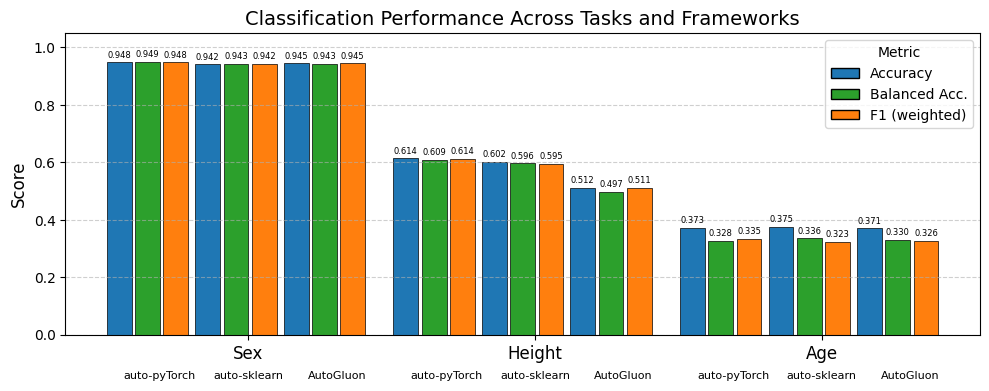

In [ ]:
task_names = [
    "sex_classification",
    "height_bracket_classification",
    "age_bracket_classification",
]

display_tasks = ["Sex", "Height", "Age"]
metrics = ["accuracy", "balanced_accuracy", "f1_weighted"]
metric_labels = ["Accuracy", "Balanced Acc.", "F1 (weighted)"]
metric_colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]

bar_width = 0.07
gap_between_frameworks = 0.02
gap_between_tasks = 0.08

framework_width = 3 * bar_width + 2 * 0.01
task_width = framework_width * len(frameworks) + gap_between_frameworks * (len(frameworks) - 1)
task_centers = np.arange(len(task_names)) * (task_width + gap_between_tasks)

fig, ax = plt.subplots(figsize=(10, 4))

# balanced_accuracy bleibt neben Accuracy und F1 sichtbar, weil Klassenverteilungen unterschiedlich sein können.
for task_idx, task_name in enumerate(task_names):
    task_center = task_centers[task_idx]
    left_edge = task_center - task_width / 2

    for framework_idx, framework in enumerate(frameworks):
        results = benchmarks[framework][300]["results"]
        framework_start = left_edge + framework_idx * (
            framework_width + gap_between_frameworks
        )

        for metric_idx, metric in enumerate(metrics):
            bar_left = framework_start + metric_idx * (bar_width + 0.01)
            value = extract_metric(results, task_name, metric, "classification")

            ax.bar(
                bar_left,
                value,
                width=bar_width,
                color=metric_colors[metric_idx],
                edgecolor="black",
                linewidth=0.5
            )
            ax.text(
                bar_left,
                value + 0.01,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=6
            )

# Die Framework-Namen stehen unter jedem Task, damit die Gruppierung trotz einer gemeinsamen x-Achse eindeutig bleibt.
for task_idx in range(len(task_names)):
    task_center = task_centers[task_idx]
    left_edge = task_center - task_width / 2

    for framework_idx in range(len(frameworks)):
        framework_center = (
            left_edge
            + framework_idx * (framework_width + gap_between_frameworks)
            + framework_width / 2
        )
        ax.text(
            framework_center,
            -0.12,
            frameworks[framework_idx],
            ha="center",
            va="top",
            fontsize=8,
            transform=ax.get_xaxis_transform()
        )

ax.set_xticks(task_centers)
ax.set_xticklabels(display_tasks, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Classification Performance Across Tasks and Frameworks", fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_ylim(0, 1.05)

legend_elements = [
    Patch(facecolor=metric_colors[i], edgecolor="black", label=metric_labels[i])
    for i in range(len(metrics))
]
ax.legend(handles=legend_elements, loc="upper right", title="Metric")

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig("classification_tight_spacing.png", dpi=300, bbox_inches="tight")
plt.show()

## Force Prediction Regression

Hier werden die R²-Werte über Bewegungsrichtung und Anteil des Gangzyklus verglichen.

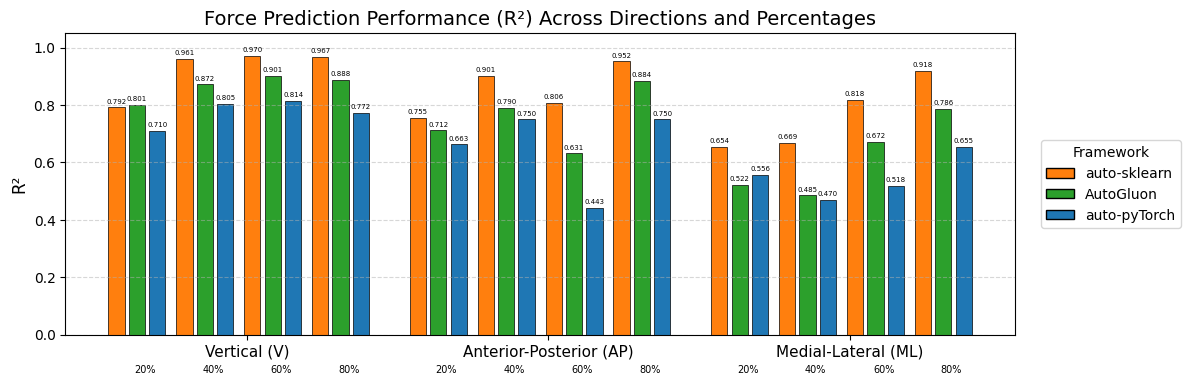

In [4]:
framework_order = ["auto-sklearn", "AutoGluon", "auto-pyTorch"]
directions = ["F_V_PRO_", "F_AP_PRO_", "F_ML_PRO_"]
display_directions = ["Vertical (V)", "Anterior-Posterior (AP)", "Medial-Lateral (ML)"]
percentages = [20, 40, 60, 80]
framework_colors = ["#ff7f0e", "#2ca02c", "#1f77b4"]

bar_width = 0.06
gap_between_frameworks = 0.015
gap_between_percentages = 0.04
gap_between_directions = 0.15

percentage_group_width = 3 * bar_width + 2 * gap_between_frameworks
direction_width = 4 * percentage_group_width + 3 * gap_between_percentages
total_unit = direction_width + gap_between_directions
direction_centers = np.arange(len(directions)) * total_unit

fig, ax = plt.subplots(figsize=(12, 4))

for direction_idx, direction in enumerate(directions):
    direction_center = direction_centers[direction_idx]
    left_edge = direction_center - direction_width / 2

    for percentage_idx, percentage in enumerate(percentages):
        percentage_start = left_edge + percentage_idx * (
            percentage_group_width + gap_between_percentages
        )

        for framework_idx, framework in enumerate(framework_order):
            results = benchmarks[framework][300]["results"]

            matching_results = [
                result for result in results
                if result.get("task_type") == "regression"
                and result.get("task", "").startswith("predict_F_")
                and result.get("direction") == direction
                and result.get("percent_of_cycle") == percentage
            ]

            value = matching_results[0].get("r2")
            bar_left = percentage_start + framework_idx * (
                bar_width + gap_between_frameworks
            )

            ax.bar(
                bar_left,
                value,
                width=bar_width,
                color=framework_colors[framework_idx],
                edgecolor="black",
                linewidth=0.5
            )
            ax.text(
                bar_left,
                value + 0.01,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=5
            )

        percentage_center = percentage_start + percentage_group_width / 2
        ax.text(
            percentage_center,
            -0.10,
            f"{percentage}%",
            ha="center",
            va="top",
            fontsize=7,
            transform=ax.get_xaxis_transform()
        )

ax.set_xticks(direction_centers)
ax.set_xticklabels(display_directions, fontsize=11)
ax.set_ylabel("R²", fontsize=12)
ax.set_title("Force Prediction Performance (R²) Across Directions and Percentages", fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(0, 1.05)

legend_elements = [
    Patch(facecolor=framework_colors[0], edgecolor="black", label="auto-sklearn"),
    Patch(facecolor=framework_colors[1], edgecolor="black", label="AutoGluon"),
    Patch(facecolor=framework_colors[2], edgecolor="black", label="auto-pyTorch")
]
ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="Framework"
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, right=0.85)
plt.savefig("regression_r2_legend_right.png", dpi=300, bbox_inches="tight")
plt.show()

## Total Training Time

Die aufsummierte Trainingszeit zeigt, wie stark sich das Zeitlimit von 300 auf 600 Sekunden auf den tatsächlichen Rechenaufwand auswirkt.

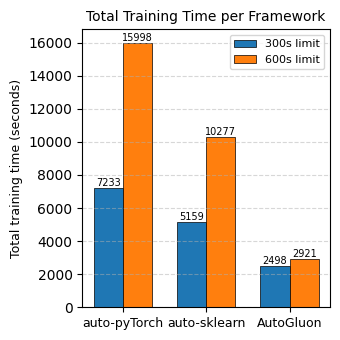

In [5]:
times_300 = [
    total_training_time(benchmarks[framework][300]["results"])
    for framework in frameworks
]
times_600 = [
    total_training_time(benchmarks[framework][600]["results"])
    for framework in frameworks
]

x = np.arange(len(frameworks))
width = 0.35

fig, ax = plt.subplots(figsize=(3.5, 3.5))

for i, limit in enumerate(time_limits):
    values = times_300 if limit == 300 else times_600

    ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=f"{limit}s limit",
        color=["#1f77b4", "#ff7f0e", "#2ca02c"][i],
        edgecolor="black",
        linewidth=0.5
    )

    for j, value in enumerate(values):
        ax.text(
            x[j] + (i - 0.5) * width,
            value,
            f"{value:.0f}",
            ha="center",
            va="bottom",
            fontsize=7
        )

ax.set_xticks(x)
ax.set_xticklabels(frameworks, fontsize=9)
ax.set_ylabel("Total training time (seconds)", fontsize=9)
ax.set_title("Total Training Time per Framework", fontsize=10)
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("training_time_total.png", dpi=300, bbox_inches="tight")
plt.show()

## Performance Comparison: 300s vs 600s

Der abschließende Plot bündelt die wichtigsten Klassifikations- und Regressionsaufgaben, um den Einfluss des höheren Zeitlimits direkt zu vergleichen.

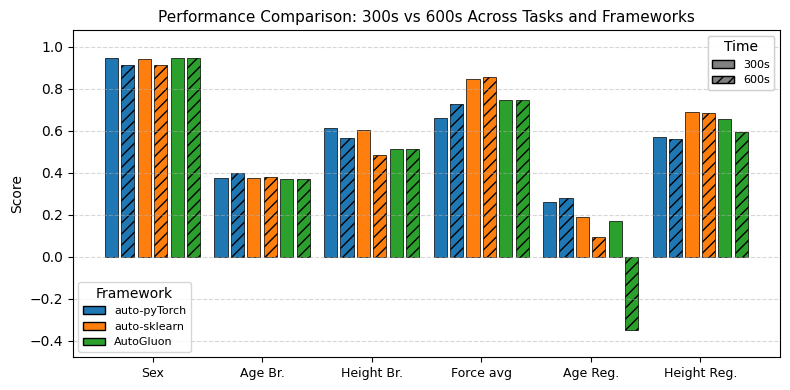

In [6]:
task_labels = ["Sex", "Age Br.", "Height Br.", "Force avg", "Age Reg.", "Height Reg."]

fig, ax = plt.subplots(figsize=(8, 4))

all_values = []
x = np.arange(len(task_labels))
bar_width = 0.12
offset_positions = np.linspace(-0.375, 0.375, 6)
framework_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# 300s vs. 600s, um den Nutzen des höheren Zeitlimits über alle Tasks hinweg zu zeigen.
for framework_idx, framework in enumerate(frameworks):
    results_300 = benchmarks[framework][300]["results"]
    results_600 = benchmarks[framework][600]["results"]

    values_300 = [
        extract_metric(results_300, "sex_classification", "accuracy", "classification"),
        extract_metric(results_300, "age_bracket_classification", "accuracy", "classification"),
        extract_metric(results_300, "height_bracket_classification", "accuracy", "classification"),
        mean_force_r2(results_300),
        extract_metric(results_300, "age_regression", "r2", "regression"),
        extract_metric(results_300, "height_regression", "r2", "regression"),
    ]
    values_600 = [
        extract_metric(results_600, "sex_classification", "accuracy", "classification"),
        extract_metric(results_600, "age_bracket_classification", "accuracy", "classification"),
        extract_metric(results_600, "height_bracket_classification", "accuracy", "classification"),
        mean_force_r2(results_600),
        extract_metric(results_600, "age_regression", "r2", "regression"),
        extract_metric(results_600, "height_regression", "r2", "regression"),
    ]

    all_values.extend(values_300)
    all_values.extend(values_600)

    ax.bar(
        x + offset_positions[framework_idx * 2],
        values_300,
        width=bar_width,
        color=framework_colors[framework_idx],
        edgecolor="black",
        linewidth=0.5
    )
    ax.bar(
        x + offset_positions[framework_idx * 2 + 1],
        values_600,
        width=bar_width,
        color=framework_colors[framework_idx],
        hatch="///",
        edgecolor="black",
        linewidth=0.5
    )

ax.set_xticks(x)
ax.set_xticklabels(task_labels, fontsize=9, rotation=0)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("Performance Comparison: 300s vs 600s Across Tasks and Frameworks", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

valid_values = [value for value in all_values if value is not None]
if valid_values:
    min_value = min(valid_values)
    max_value = max(valid_values)
    margin = (max_value - min_value) * 0.1 if max_value > min_value else 0.05
    ax.set_ylim(min_value - margin, max_value + margin)

framework_handles = [
    Patch(facecolor=framework_colors[i], edgecolor="black", label=frameworks[i])
    for i in range(len(frameworks))
]
framework_legend = ax.legend(
    handles=framework_handles,
    loc="lower left",
    fontsize=8,
    title="Framework"
)

time_handles = [
    Patch(facecolor="gray", edgecolor="black", hatch="", label="300s"),
    Patch(facecolor="gray", edgecolor="black", hatch="///", label="600s")
]
time_legend = ax.legend(
    handles=time_handles,
    loc="upper right",
    fontsize=8,
    title="Time"
)

ax.add_artist(framework_legend)
ax.add_artist(time_legend)

plt.tight_layout()
plt.savefig("performance_two_legends_bottom_left.png", dpi=300, bbox_inches="tight")
plt.show()